# Load Dependencies

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc
import torch.optim as optim

---
# Load File

In [ ]:
file = "/groups/GE264/zross/HW4/phaselink.npz"
df = np.load(file)
X = df["X"]
y = df["Y"]
print(X.shape)
print(y.shape)

(100000, 500, 5)
(100000, 500)


---
# Dataset class

In [ ]:
class SeqDataset(Dataset):
    """Dataset for sequence data (e.g., time series, text sequences)"""
    def __init__(self, sequences, labels):
        """
        Args:
            sequences: numpy array of shape (n_samples, seq_length, n_features)
            labels: numpy array of shape (n_samples,) with integer class labels
        """
        self.sequences = torch.from_numpy(sequences).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

---
# Trainer Class

In [ ]:
class Trainer:
    def __init__(self, model, optimizer, device=None, name=None):
        """
        Initialize the Trainer for sequence models.

        Args:
            model (nn.Module): The PyTorch sequence model (RNN, LSTM, GRU, etc.)
            optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.
            device (torch.device, optional): Device to use (GPU or CPU).
            name (str, optional): Name for the model/trainer.
        """
        self.model = model
        self.optimizer = optimizer

        self.criterion = nn.BCELoss()

        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.history = None
        self.name = name if name else "Model"

    def _compute_metrics(self, outputs, labels):
        """
        Compute accuracy, precision, and recall for both classes.

        Args:
            outputs: Model outputs (logits), shape (batch_size * seq_len, 1)
            labels: True labels, shape (batch_size * seq_len,)

        Returns:
            dict with accuracy, precision_0, precision_1, recall_0, recall_1
        """

        # Convert to binary predictions from RNN
        preds = (outputs > 0.5).long().squeeze(-1)

        # Accuracy
        correct = (preds == labels).sum().item()
        accuracy = correct / labels.size(0)

        preds_np = preds.cpu().numpy()
        labels_np = labels.cpu().numpy()

        # Compute precision and recall for each class
        metrics = {'accuracy': accuracy}

        for class_id in [0, 1]:
            tp = np.sum((preds_np == class_id) & (labels_np == class_id))
            fp = np.sum((preds_np == class_id) & (labels_np != class_id))
            fn = np.sum((preds_np != class_id) & (labels_np == class_id))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

            metrics[f'precision_{class_id}'] = precision
            metrics[f'recall_{class_id}'] = recall

        return metrics

    def train(self, train_loader, val_loader, max_epochs=10):
        """
        Train the model and track metrics including precision and recall.

        Args:
            train_loader (DataLoader): Training dataset loader.
            val_loader (DataLoader): Validation dataset loader.
            max_epochs (int): Max number of training epochs.
        """
        history = {
            "train_loss": [], "val_loss": [],
            "train_acc": [], "val_acc": [],
            "train_precision_0": [], "train_precision_1": [],
            "train_recall_0": [], "train_recall_1": [],
            "val_precision_0": [], "val_precision_1": [],
            "val_recall_0": [], "val_recall_1": []
        }

        print(f"Training history for {self.name}")
        print("=" * 80)
        tol = 1e-6
        conv_count = 0
        for epoch in range(1, max_epochs + 1):

            # ----------------------
            # Training phase
            # ----------------------
            self.model.train()
            running_loss = 0.0
            all_outputs = []
            all_labels = []

            for sequences, labels in train_loader:
                sequences, labels = sequences.to(self.device), labels.to(self.device)

                # flatten labels for seq2seq
                labels_flat = labels.reshape(-1).float()

                # Forward pass
                outputs = self.model(sequences)  # (B, T, 1)

                # flatten outputs to match labels
                outputs_flat = outputs.reshape(-1, 1)

                loss = self.criterion(outputs_flat, labels_flat.unsqueeze(1))

                # Backward pass
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item() * sequences.size(0)
                all_outputs.append(outputs_flat.detach().cpu())
                all_labels.append(labels_flat.cpu())

            # Compute training metrics
            train_loss = running_loss / len(train_loader.dataset)
            all_outputs = torch.cat(all_outputs)
            all_labels = torch.cat(all_labels)
            train_metrics = self._compute_metrics(all_outputs, all_labels)

            # ----------------------
            # Validation phase
            # ----------------------
            self.model.eval()
            val_loss = 0.0
            all_val_outputs = []
            all_val_labels = []

            with torch.no_grad():
                for sequences, labels in val_loader:
                    sequences, labels = sequences.to(self.device), labels.to(self.device)

                    labels_flat = labels.reshape(-1).float()
                    outputs = self.model(sequences)
                    outputs_flat = outputs.reshape(-1, 1)

                    loss = self.criterion(outputs_flat, labels_flat.unsqueeze(1))

                    val_loss += loss.item() * sequences.size(0)
                    all_val_outputs.append(outputs_flat.cpu())
                    all_val_labels.append(labels_flat.cpu())

            # Compute validation metrics
            val_loss /= len(val_loader.dataset)
            all_val_outputs = torch.cat(all_val_outputs)
            all_val_labels = torch.cat(all_val_labels)
            val_metrics = self._compute_metrics(all_val_outputs, all_val_labels)

            # Store history
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_metrics['accuracy'])
            history["val_acc"].append(val_metrics['accuracy'])

            for class_id in [0, 1]:
                history[f"train_precision_{class_id}"].append(train_metrics[f'precision_{class_id}'])
                history[f"train_recall_{class_id}"].append(train_metrics[f'recall_{class_id}'])
                history[f"val_precision_{class_id}"].append(val_metrics[f'precision_{class_id}'])
                history[f"val_recall_{class_id}"].append(val_metrics[f'recall_{class_id}'])

            if epoch == 1:
                prev_val_loss = val_loss
                print(f"Epoch {epoch}")
                print(f"  Train - Loss: {train_loss:.5f}, Acc: {train_metrics['accuracy']:.5f}, "
                      f"Precision (P-Wave): {train_metrics['precision_0']:.5f}, Recall (P-Wave): {train_metrics['recall_0']:.5f}, "
                      f"Precision (S-Wave): {train_metrics['precision_1']:.5f}, Recall (S-Wave): {train_metrics['recall_1']:.5f}")
                print(f"  Val   - Loss: {val_loss:.5f}, Acc: {val_metrics['accuracy']:.5f}, "
                      f"Precision (P-Wave): {val_metrics['precision_0']:.5f}, Recall (P-Wave): {val_metrics['recall_0']:.5f}, "
                      f"Precision (S-Wave): {val_metrics['precision_1']:.5f}, Recall (S-Wave): {val_metrics['recall_1']:.5f}")
                print()
            else:
                if abs(val_loss - prev_val_loss) < tol:
                    conv_count += 1
                    if conv_count == 5:
                        print(f"Epoch {epoch}")
                        print(f"  Train - Loss: {train_loss:.5f}, Acc: {train_metrics['accuracy']:.5f}, "
                              f"Precision (P-Wave): {train_metrics['precision_0']:.5f}, Recall (P-Wave): {train_metrics['recall_0']:.5f}, "
                              f"Precision (S-Wave): {train_metrics['precision_1']:.5f}, Recall (S-Wave): {train_metrics['recall_1']:.5f}")
                        print(f"  Val   - Loss: {val_loss:.5f}, Acc: {val_metrics['accuracy']:.5f}, "
                              f"Precision (P-Wave): {val_metrics['precision_0']:.5f}, Recall (P-Wave): {val_metrics['recall_0']:.5f}, "
                              f"Precision (S-Wave): {val_metrics['precision_1']:.5f}, Recall (S-Wave): {val_metrics['recall_1']:.5f}")
                        print()
                        print("Convergence criterion met. Stopping early.\n")
                        break
                if epoch % 10 == 0 or epoch == max_epochs:
                    # Print progress
                    print(f"Epoch {epoch}")
                    print(f"  Train - Loss: {train_loss:.5f}, Acc: {train_metrics['accuracy']:.5f}, "
                          f"Precision (P-Wave): {train_metrics['precision_0']:.5f}, Recall (P-Wave): {train_metrics['recall_0']:.5f}, "
                          f"Precision (S-Wave): {train_metrics['precision_1']:.5f}, Recall (S-Wave): {train_metrics['recall_1']:.5f}")
                    print(f"  Val   - Loss: {val_loss:.5f}, Acc: {val_metrics['accuracy']:.5f}, "
                          f"Precision (P-Wave): {val_metrics['precision_0']:.5f}, Recall (P-Wave): {val_metrics['recall_0']:.5f}, "
                          f"Precision (S-Wave): {val_metrics['precision_1']:.5f}, Recall (S-Wave): {val_metrics['recall_1']:.5f}")
                    print()
                prev_val_loss = val_loss
        self.history = history

---
# Miscellaneous Functions

In [ ]:
def plot_sequence(sequence, label=None, sequence_num=0):

    # Extract features
    latitudes = sequence[:, 0]
    longitudes = sequence[:, 1]
    times = sequence[:, 2]
    phase_types = sequence[:, 3]  # 0 = P-wave, 1 = S-wave

    # Create color array based on phase type
    colors = ['blue' if pt == 0 else 'red' for pt in phase_types]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Time vs Latitude
    axes[0].scatter(times, latitudes, c=colors, alpha=0.6, s=50)
    axes[0].set_xlabel('Time (s)', fontsize=12)
    axes[0].set_ylabel('Latitude', fontsize=12)
    axes[0].set_title(f'Time vs Latitude - Sequence {sequence_num}', fontsize=14)
    axes[0].grid(True, alpha=0.3)

    # Time vs Longitude
    axes[1].scatter(times, longitudes, c=colors, alpha=0.6, s=50)
    axes[1].set_xlabel('Time (s)', fontsize=12)
    axes[1].set_ylabel('Longitude', fontsize=12)
    axes[1].set_title(f'Time vs Longitude - Sequence {sequence_num}', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Create custom legend
    legend_elements = [
        Patch(facecolor='blue', label='P-wave'),
        Patch(facecolor='red', label='S-wave')
    ]
    axes[0].legend(handles=legend_elements, loc=2)
    axes[1].legend(handles=legend_elements, loc=2)

    plt.tight_layout()
    plt.show()

def plot_training_curves(histories, title=None, param=None):
    """
    Plot train/val: loss & accuracy, precision & recall (P-Wave), and precision & recall (S-Wave) curves
    """
    if param:
        for lam, hist in sorted(histories.items(), key=lambda x: x[0]):
            fig, axes = plt.subplots(3, 2, figsize=(14, 10))

            # Loss
            axes[0, 0].plot(hist["train_loss"], label="Train")
            axes[0, 0].plot(hist["val_loss"], label="Val")

            # Accuracy
            axes[0, 1].plot(hist["train_acc"], label="Train")
            axes[0, 1].plot(hist["val_acc"], label="Val")

            # Precision
            axes[1, 0].plot(hist["train_precision_0"], label="Train")
            axes[1, 0].plot(hist["val_precision_0"], label="Val")

            axes[2, 0].plot(hist["train_precision_1"], label="Train")
            axes[2, 0].plot(hist["val_precision_1"], label="Val")

            # Recall
            axes[1, 1].plot(hist["train_recall_0"], label="Train")
            axes[1, 1].plot(hist["val_recall_0"], label="Val")

            axes[2, 1].plot(hist["train_recall_1"], label="Train")
            axes[2, 1].plot(hist["val_recall_1"], label="Val")

            # Titles and labels
            axes[0, 0].set_title("Loss")
            axes[0, 0].set_xlabel("Epoch")
            axes[0, 0].set_ylabel("Loss")
            axes[0, 0].grid(True)
            axes[0, 0].legend()

            axes[0, 1].set_title("Accuracy")
            axes[0, 1].set_xlabel("Epoch")
            axes[0, 1].set_ylabel("Accuracy")
            axes[0, 1].grid(True)
            axes[0, 1].legend()

            axes[1, 0].set_title("Precision (P-Wave)")
            axes[1, 0].set_xlabel("Epoch")
            axes[1, 0].set_ylabel("Precision")
            axes[1, 0].grid(True)
            axes[1, 0].legend()

            axes[1, 1].set_title("Recall (P-Wave)")
            axes[1, 1].set_xlabel("Epoch")
            axes[1, 1].set_ylabel("Recall")
            axes[1, 1].grid(True)
            axes[1, 1].legend()

            axes[2, 0].set_title("Precision (S-Wave)")
            axes[2, 0].set_xlabel("Epoch")
            axes[2, 0].set_ylabel("Precision")
            axes[2, 0].grid(True)
            axes[2, 0].legend()

            axes[2, 1].set_title("Recall (S-Wave)")
            axes[2, 1].set_xlabel("Epoch")
            axes[2, 1].set_ylabel("Recall")
            axes[2, 1].grid(True)
            axes[2, 1].legend()

            if title:
                plt.suptitle(f"Training Curves for {title} Where {param} = {lam}", fontsize=16, fontweight='bold')
            else:
                plt.suptitle(f"Training Curves for {param} = {lam}", fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()
            print("\n\n\n")
    else:
        hist = histories
        fig, axes = plt.subplots(3, 2, figsize=(14, 10))

        # Loss
        axes[0, 0].plot(hist["train_loss"], label="Train")
        axes[0, 0].plot(hist["val_loss"], label="Val")

        # Accuracy
        axes[0, 1].plot(hist["train_acc"], label="Train")
        axes[0, 1].plot(hist["val_acc"], label="Val")

        # Precision
        axes[1, 0].plot(hist["train_precision_0"], label="Train")
        axes[1, 0].plot(hist["val_precision_0"], label="Val")

        axes[2, 0].plot(hist["train_precision_1"], label="Train")
        axes[2, 0].plot(hist["val_precision_1"], label="Val")

        # Recall
        axes[1, 1].plot(hist["train_recall_0"], label="Train")
        axes[1, 1].plot(hist["val_recall_0"], label="Val")

        axes[2, 1].plot(hist["train_recall_1"], label="Train")
        axes[2, 1].plot(hist["val_recall_1"], label="Val")

        # Titles and labels
        axes[0, 0].set_title("Loss")
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].grid(True)
        axes[0, 0].legend()

        axes[0, 1].set_title("Accuracy")
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("Accuracy")
        axes[0, 1].grid(True)
        axes[0, 1].legend()

        axes[1, 0].set_title("Precision (P-Wave)")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Precision")
        axes[1, 0].grid(True)
        axes[1, 0].legend()

        axes[1, 1].set_title("Recall (P-Wave)")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Recall")
        axes[1, 1].grid(True)
        axes[1, 1].legend()

        axes[2, 0].set_title("Precision (S-Wave)")
        axes[2, 0].set_xlabel("Epoch")
        axes[2, 0].set_ylabel("Precision")
        axes[2, 0].grid(True)
        axes[2, 0].legend()

        axes[2, 1].set_title("Recall (S-Wave)")
        axes[2, 1].set_xlabel("Epoch")
        axes[2, 1].set_ylabel("Recall")
        axes[2, 1].grid(True)
        axes[2, 1].legend()
        if title:
            plt.suptitle(f"Training Curves for {title}", fontsize=16, fontweight='bold')
        else:
            plt.suptitle(f"Training Curves", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print("\n\n\n")

In [ ]:
def summarize_best_epoch(history, title):
    # Find the epoch with highest validation accuracy
    val_acc = history["val_acc"]
    best_epoch = int(np.argmax(val_acc))   # index of best epoch
    print(f"Model Summary for {title}")
    print("=" * 80)
    print(f"Best Epoch: {best_epoch + 1}")  # +1 for human-friendly epoch numbering
    print(f"Categorical Accuracy: {val_acc[best_epoch]:.4f}")

    print("\nPrecision and Recall per class:")
    print(f"  P-Wave - Precision: {history['val_precision_0'][best_epoch]:.4f}, "
          f"Recall: {history['val_recall_0'][best_epoch]:.4f}")

    print(f"  S-Wave - Precision: {history['val_precision_1'][best_epoch]:.4f}, "
          f"Recall: {history['val_recall_1'][best_epoch]:.4f} \n\n")

---
# Data Analysis

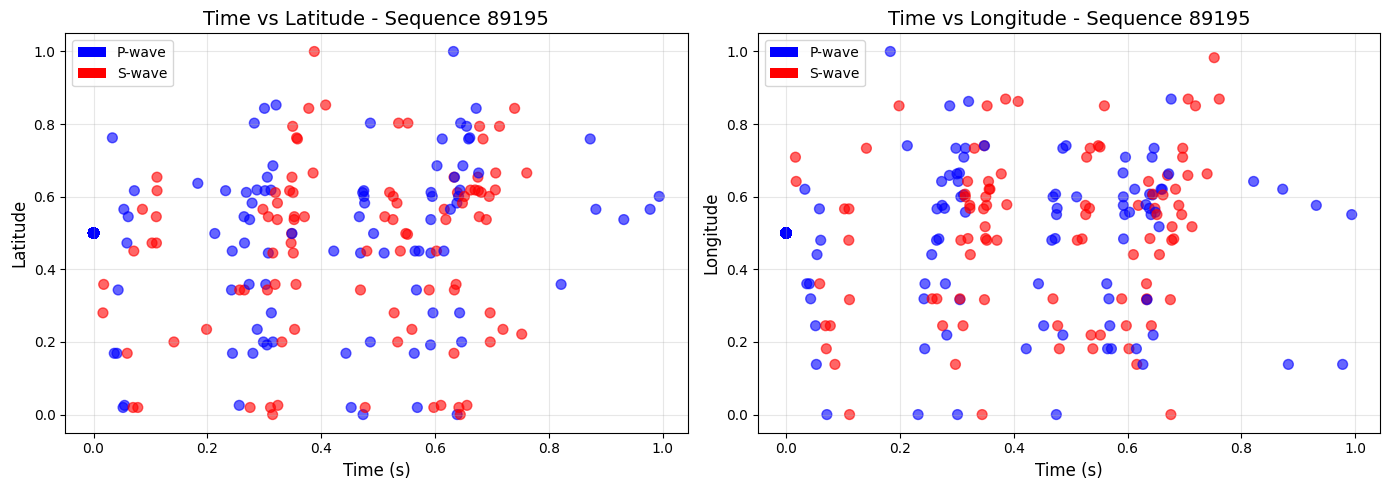

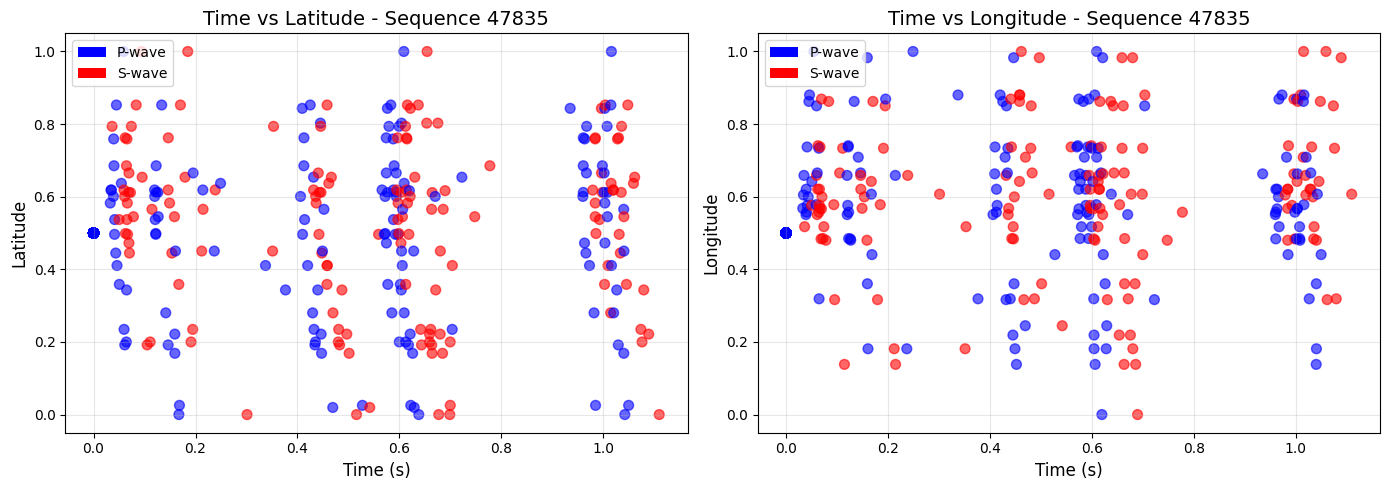

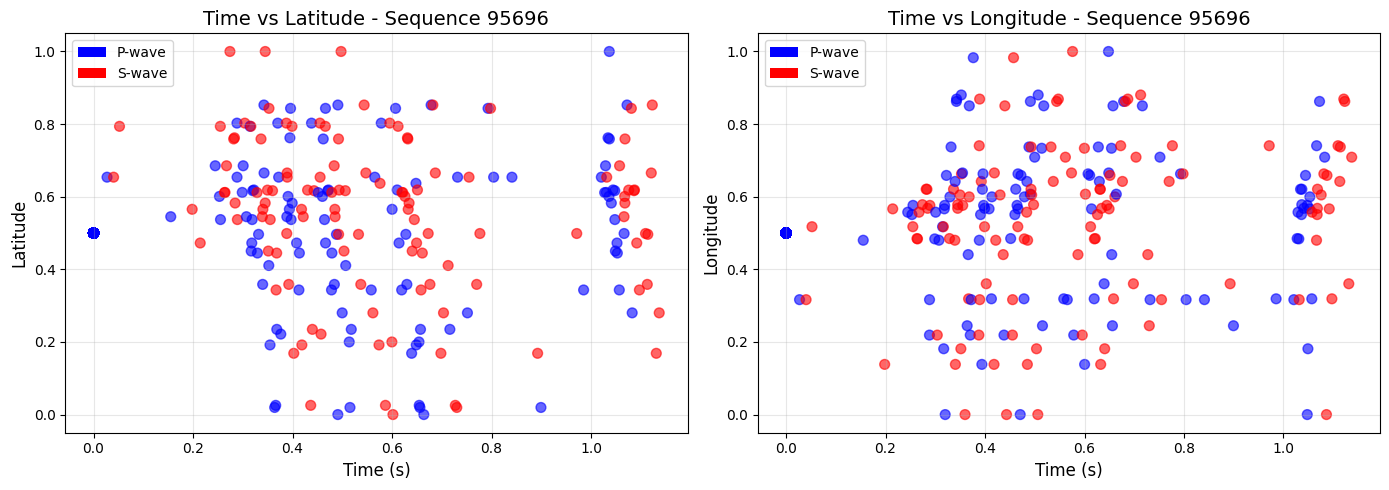

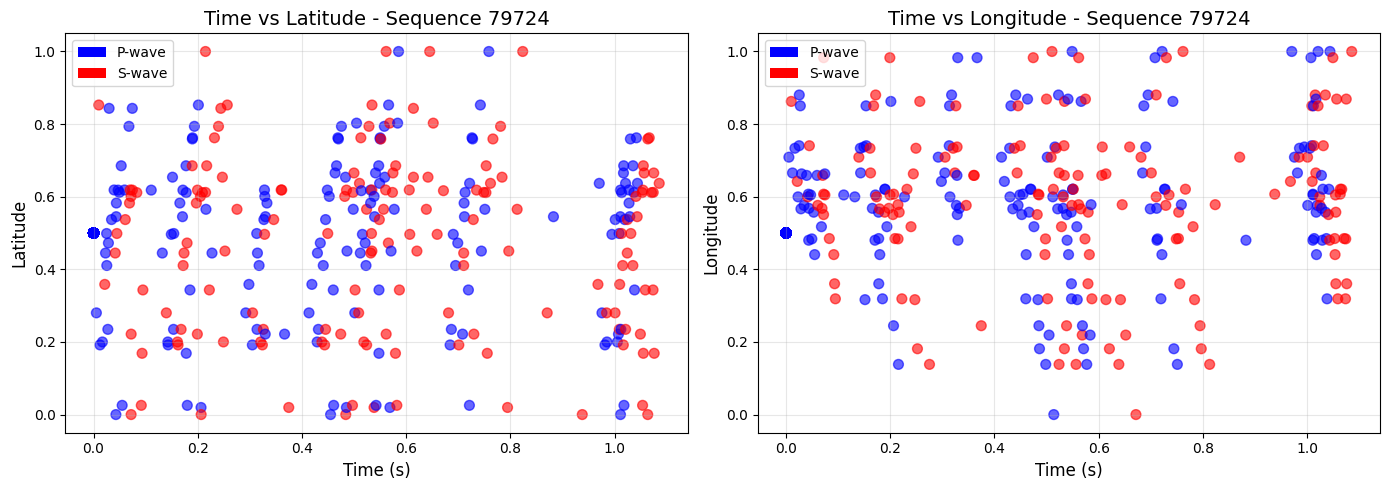

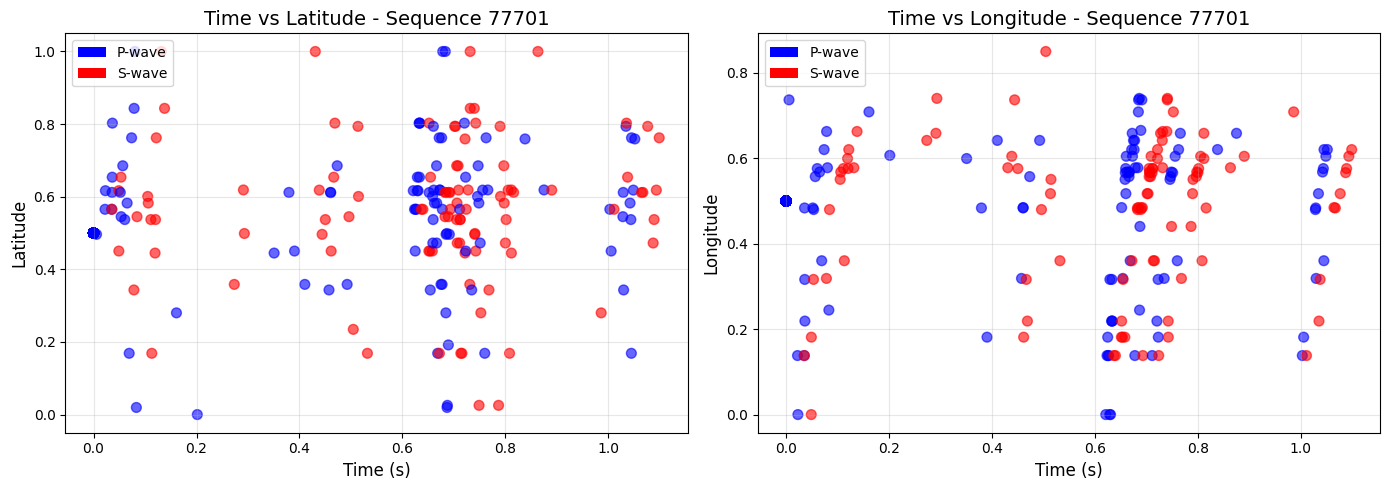

In [ ]:
# Plot random sequences
num_seq = 5
indices = np.random.randint(0, len(X), size=num_seq)

for i, idx in enumerate(indices):
    sequence = X[idx, :, :]
    label = y[idx]
    plot_sequence(sequence, label, sequence_num=idx)

In [ ]:
# Examine distirbution of labels
num_zeros = np.sum(y == 0)
num_ones  = np.sum(y == 1)

print(f"Total number of P-waves detected: {num_zeros}")
print(f"Total number of S-waves detected: {num_ones}")
print(f"Total number of observations: {num_ones + num_zeros}")
print()
print(f"Proportion of P-waves: {num_zeros / (num_zeros + num_ones)}")
print(f"Proportion of S-waves:{num_ones / (num_zeros + num_ones)}")

Total number of P-waves detected: 48668553
Total number of S-waves detected: 1331447
Total number of observations: 50000000

Proportion of P-waves: 0.97337106
Proportion of S-waves:0.02662894


---
# Load + Split SeqDataset

In [ ]:
dataset = SeqDataset(X, y)
num_samples = len(dataset)
indices = np.arange(num_samples)
np.random.shuffle(indices)

split = int(0.8 * num_samples)
train_indices, val_indices = indices[:split], indices[split:]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

batch_size = 256

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler, num_workers=4, pin_memory=True)

---
# Model Classes

In [ ]:
class Many2ManyRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        """
        Initialize the RNN from scratch using only linear layers.

        Args:
            input_dim (int): Number of input features per time step
            hidden_dim (int): Number of hidden units
            output_dim (int): Number of output features per time step
        """
        super().__init__() # inherit nn.Module constructor
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        # Define linear layers
        self.input_to_hidden = nn.Linear(input_dim, hidden_dim, bias=True)
        self.hidden_to_hidden = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.hidden_to_output = nn.Linear(hidden_dim, output_dim, bias=True)

    def forward(self, X):
        """
        Forward pass through the RNN.

        Args:
            X: Input tensor of shape (batch_size, seq_length, input_dim)

        Returns:
            Output tensor of shape (batch_size, seq_length, output_dim)
        """
        # Extract dimensions
        batch_size, seq_length, _ = X.size()

        # Initialize hidden state
        h_t = torch.zeros(batch_size, self.hidden_dim, device=X.device)

        # Store outputs at each time step
        outputs = []

        for t in range(seq_length):
            X_t = X[:, t, :]  # Shape: (batch_size, input_dim)

            # Compute new hidden state
            h_t = self.input_to_hidden(X_t) + self.hidden_to_hidden(h_t)

            # Apply tanh activation to hidden state
            h_t = torch.tanh(h_t)

            # Compute output at current time step
            y_t = self.hidden_to_output(h_t)

            # Apply sigmoid to output
            y_t = torch.sigmoid(y_t)

            outputs.append(y_t)

        return torch.stack(outputs, dim=1) # return output sequence, shape: (batch_size, seq_length, output_dim)
class Many2ManyLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, bidirectional=False):
        super().__init__()

        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        # If bidirectional, LSTM outputs hidden_dim * 2 features
        self.fc = nn.Linear(hidden_dim * self.num_directions, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = torch.sigmoid(self.fc(out))
        return out

---
# RNN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train Model

H = 16
max_num_epochs = 100
eta_vals = [1e-3, 1e-2, 1e-1, 1, 10]
histories = {}

for i, eta in enumerate(eta_vals):

    # instantiate model
    model = Many2ManyRNN(5, H, 1)
    model = model.to(device)

    # initialize optimizer with the model
    optimizer = optim.SGD(model.parameters(), lr=eta)

    # instantiate trainer
    trainer = Trainer(model, optimizer, device, f"RNN with lr = {eta}")

    # train
    trainer.train(train_loader, val_loader, max_num_epochs)

    # store history
    histories[eta] = trainer.history

    # delete the model and trainer to free GPU/CPU memory for the next loop
    del model
    del trainer
    del optimizer

    # force Python to release memory
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Training history for RNN with lr = 0.001
Epoch 1
  Train - Loss: 0.42226, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.10016, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 10
  Train - Loss: 0.18958, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.04582, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 20
  Train - Loss: 0.12508, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.03085, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 30
  Train - Loss: 0.10726, Acc: 0.9

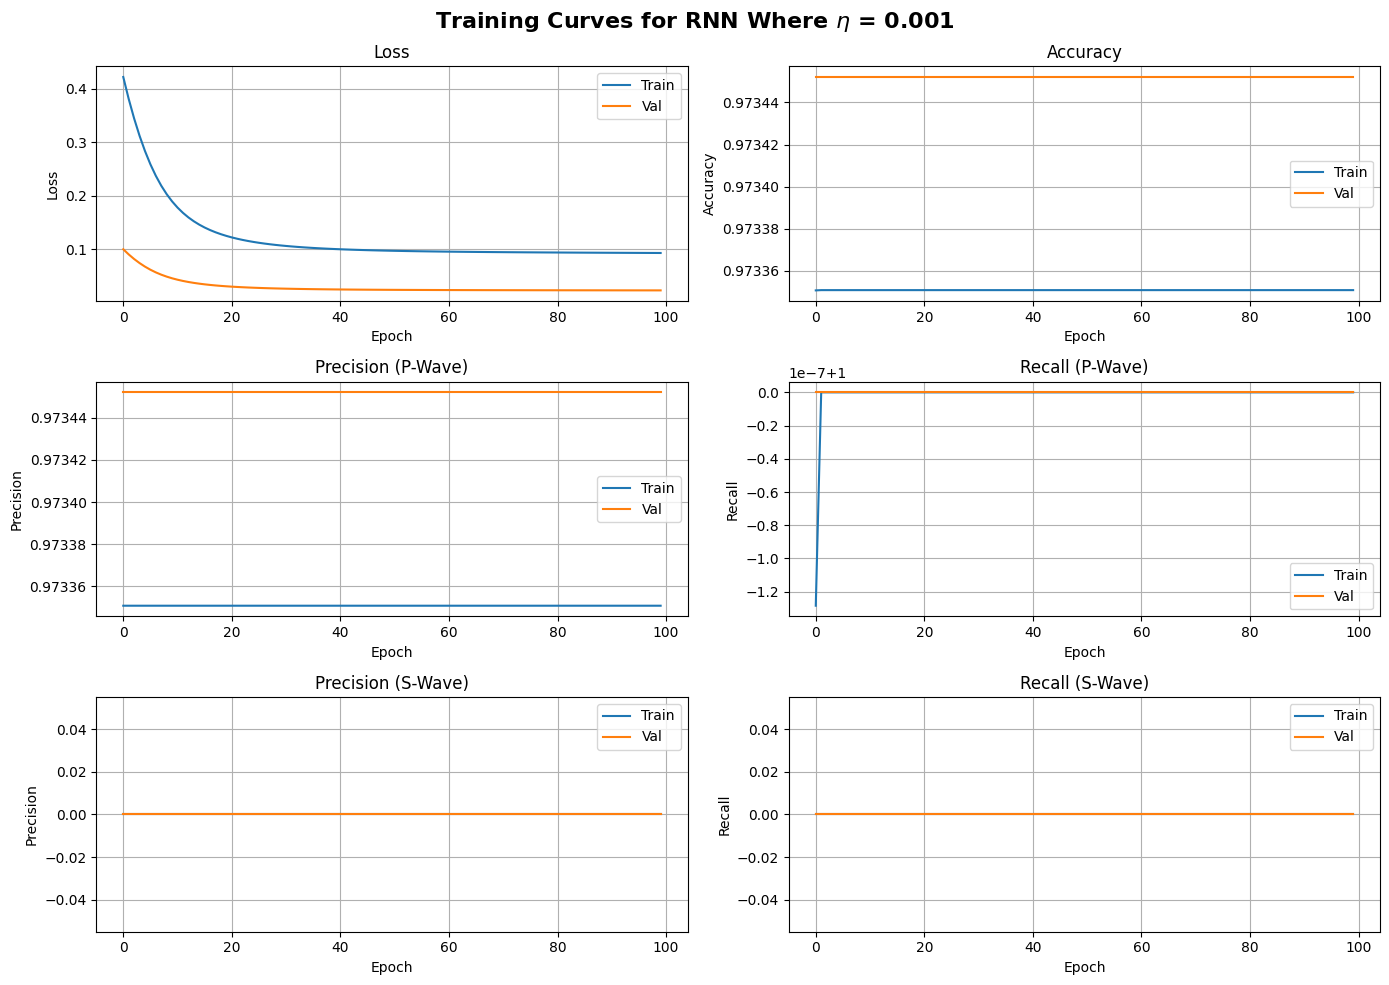

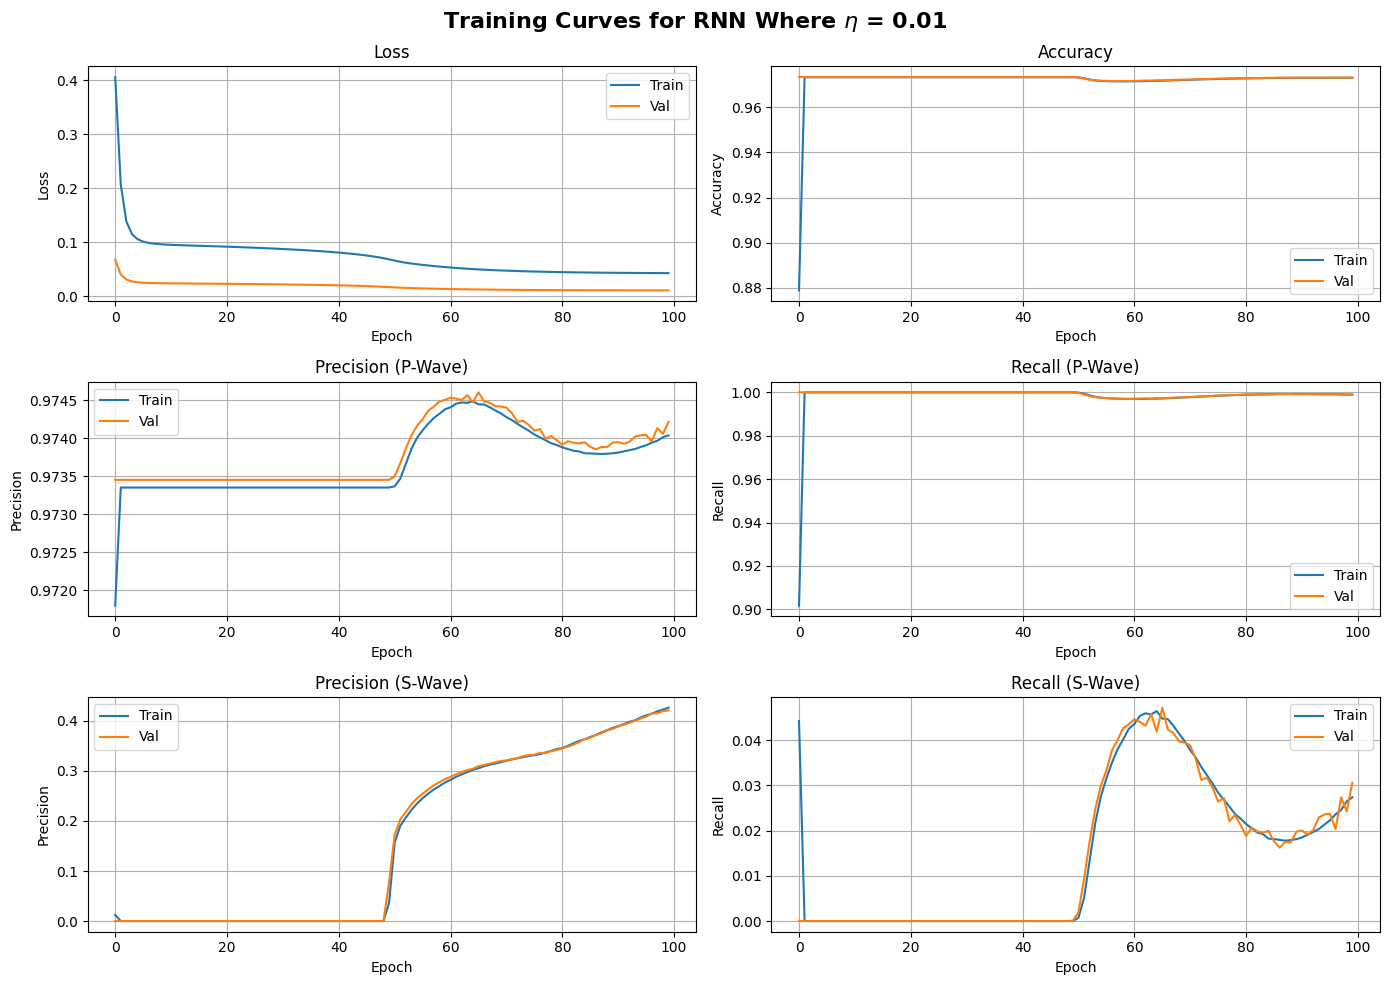

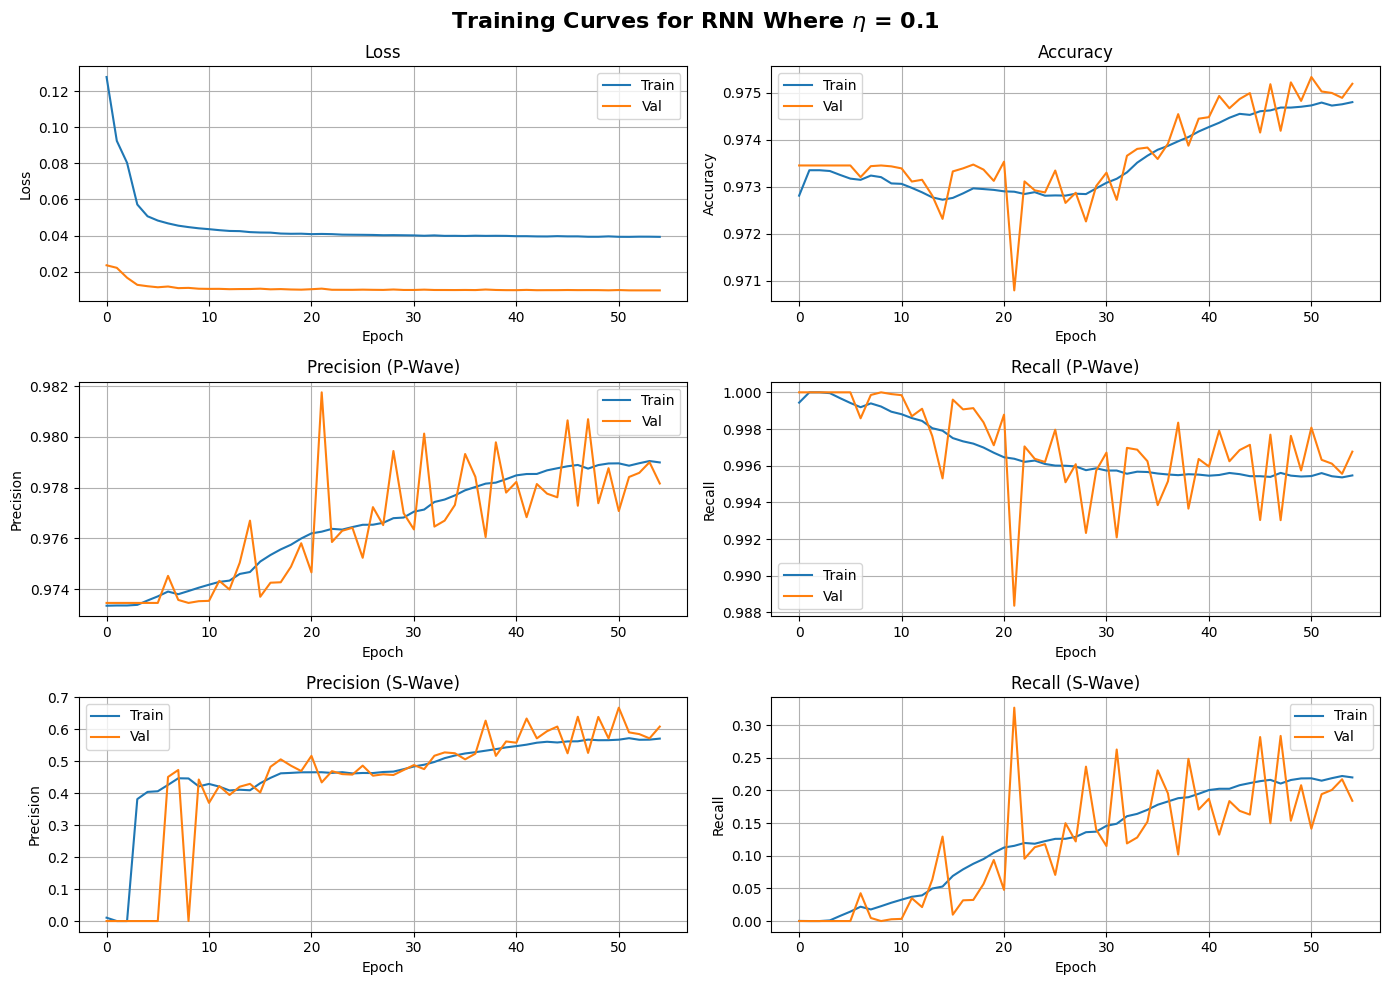

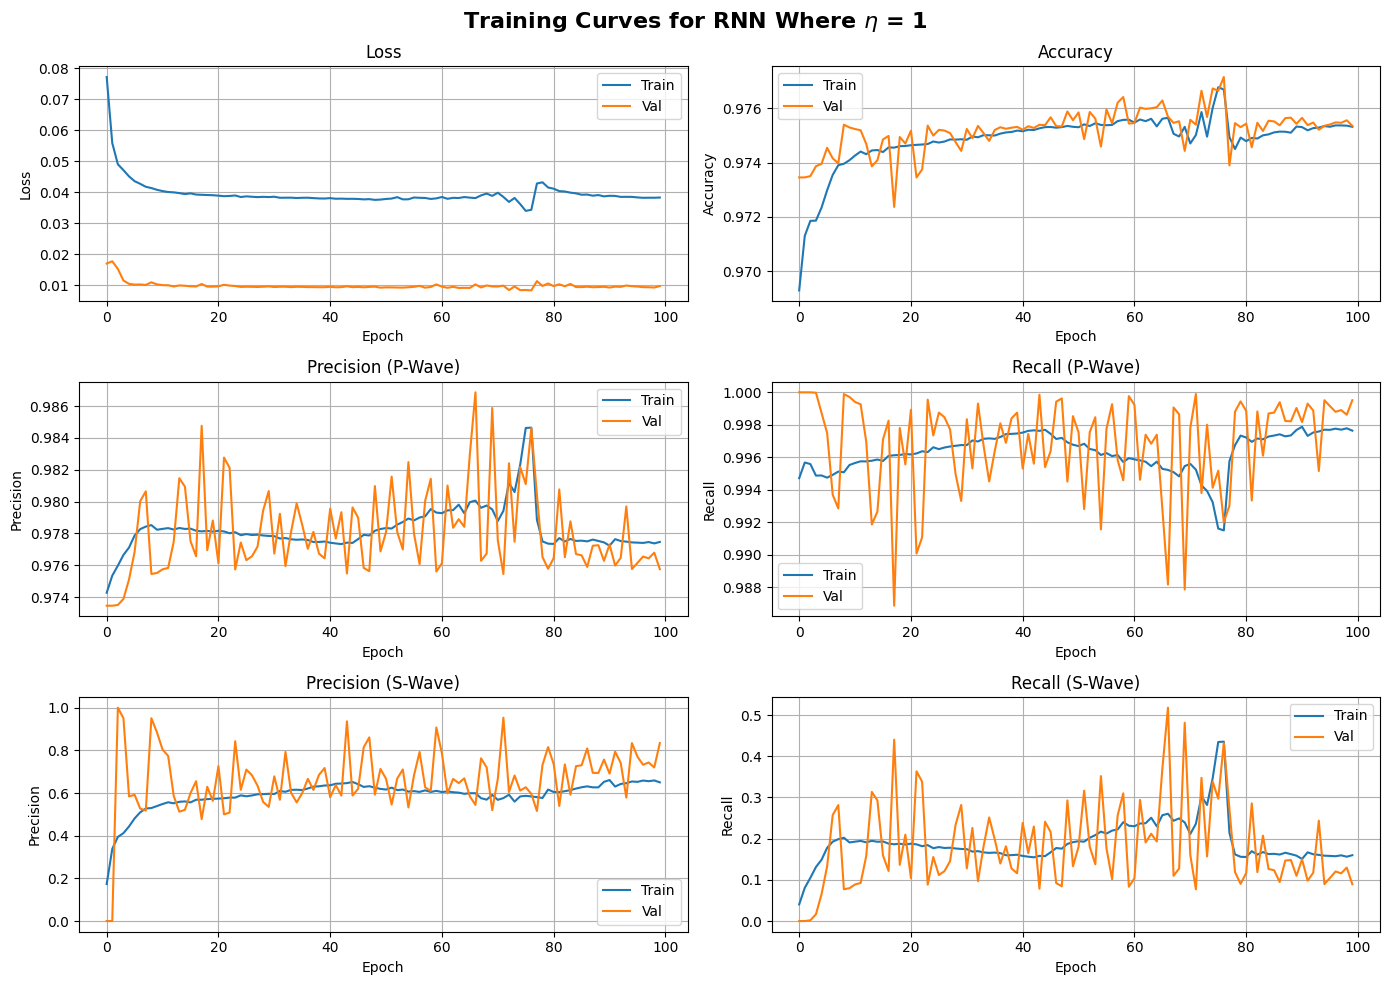

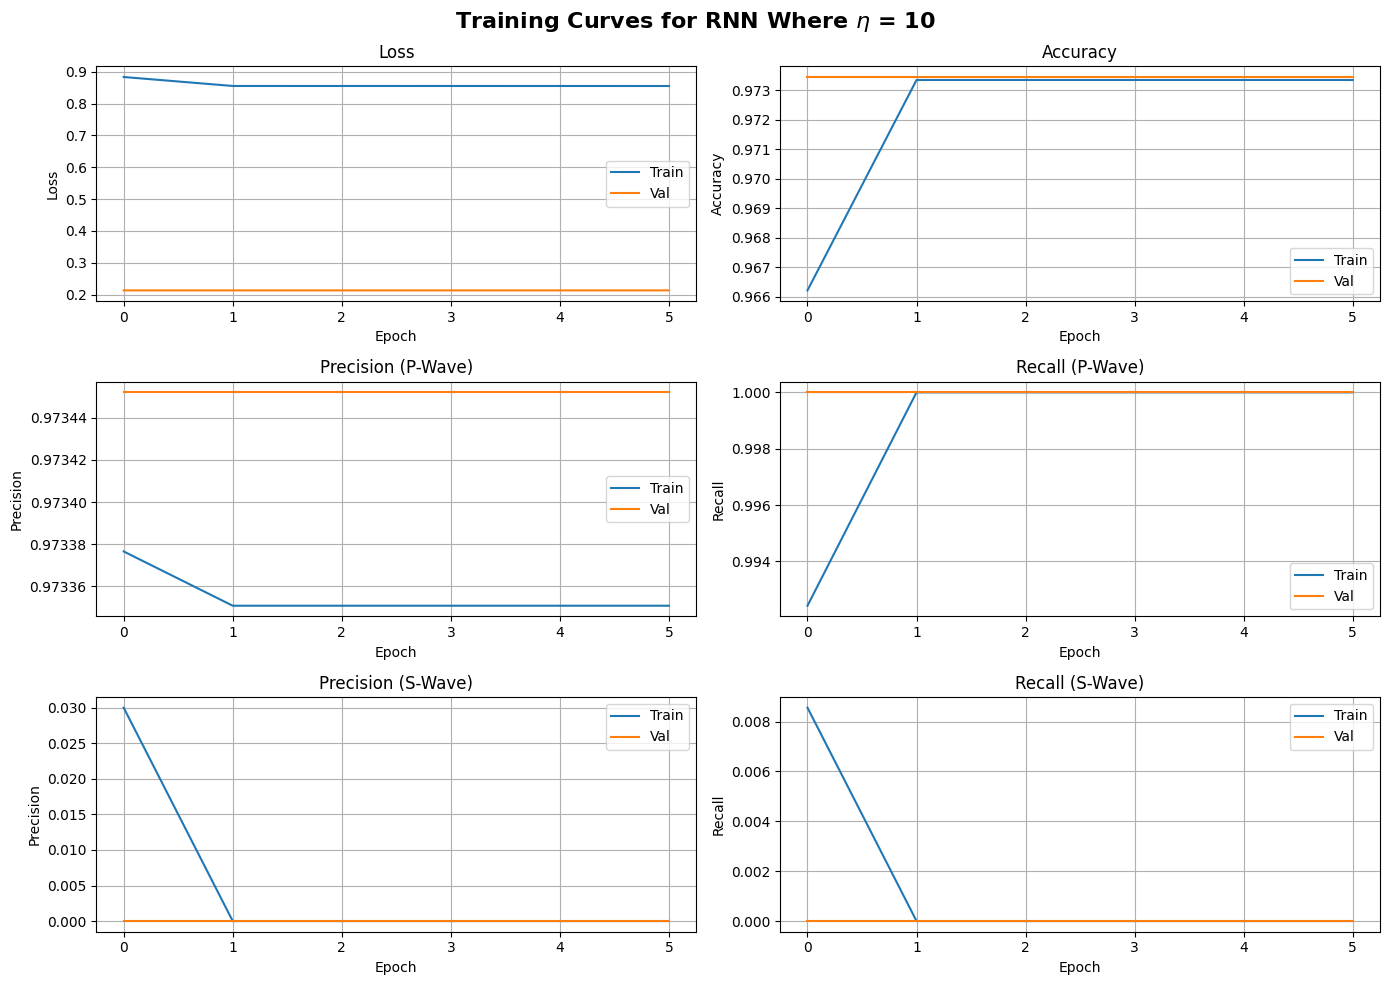

In [ ]:
plot_training_curves(histories, "RNN", "$\eta$")

In [ ]:
for eta in eta_vals:
    summarize_best_epoch(histories[eta], f"RNN with lr = {eta}")

Model Summary for RNN with lr = 0.001
Best Epoch: 1
Categorical Accuracy: 0.9735

Precision and Recall per class:
  P-Wave - Precision: 0.9735, Recall: 1.0000
  S-Wave - Precision: 0.0000, Recall: 0.0000 


Model Summary for RNN with lr = 0.01
Best Epoch: 1
Categorical Accuracy: 0.9735

Precision and Recall per class:
  P-Wave - Precision: 0.9735, Recall: 1.0000
  S-Wave - Precision: 0.0000, Recall: 0.0000 


Model Summary for RNN with lr = 0.1
Best Epoch: 51
Categorical Accuracy: 0.9753

Precision and Recall per class:
  P-Wave - Precision: 0.9771, Recall: 0.9981
  S-Wave - Precision: 0.6672, Recall: 0.1414 


Model Summary for RNN with lr = 1
Best Epoch: 77
Categorical Accuracy: 0.9772

Precision and Recall per class:
  P-Wave - Precision: 0.9846, Recall: 0.9920
  S-Wave - Precision: 0.5961, Recall: 0.4321 


Model Summary for RNN with lr = 10
Best Epoch: 1
Categorical Accuracy: 0.9735

Precision and Recall per class:
  P-Wave - Precision: 0.9735, Recall: 1.0000
  S-Wave - Precision:

---
## Effect of Learning Rate on Minority Class Detection Using RNNs

**1. Overview: The "Majority Class" Baseline**

A notable similarity exists between the models with **LR = 0.001**, **LR = 0.01**, and **LR = 10**. All three converged to an identical validation accuracy of **0.9735** with an S-Wave recall of **0.0000**.

This behavior is explained by the extreme class imbalance in the dataset. As noted in the data distribution, P-waves constitute **97.33%** of all observations.

These models failed to learn distinctive features for the S-wave. Instead, they minimized loss by converging to a "lazy" local minimum: predicting the majority class (P-wave) 100% of the time. The accuracy of **0.9735** matches the proportion of P-waves exactly, representing the *baseline* rather than true predictive skill.

---

**2. Best Performing Model: LR = 1**

The model trained with a learning rate of **1** is the most effective. While the categorical accuracy (0.9772) is only marginally higher than the baseline, the critical metric is the **S-Wave Recall of 0.4321**.

This is the only configuration that successfully escaped the local minimum of the majority class. It correctly identified over 43% of the S-waves, demonstrating that the model actually learned to distinguish between the seismic phases rather than relying on prior probabilities.

---

**3. Worst Performing Models: LR = 0.001, 0.01, and 10**

These three models are tied for worst performance as they failed to identify a single instance of the signal of interest (S-wave).

*   **Low LR (0.001, 0.01):** Updates were likely too small to push the weights out of the initial "safe" solution (predicting P-waves) toward the more complex S-wave features.
*   **High LR (10):** Likely caused gradient instability or overshooting, preventing convergence on a nuanced solution and forcing the model back to the statistical mean.

# LSTM

---
## Default Parameter LSTM

In [ ]:
H = 16
max_num_epochs = 100
lstm_model_1 = Many2ManyLSTM(input_dim=5, hidden_dim=H, output_dim=1).to(device)
optimizer = optim.Adam(lstm_model_1.parameters())
trainer = Trainer(lstm_model_1, optimizer, device, "LSTM model 1")
trainer.train(train_loader, val_loader, max_num_epochs)
lstm_hist_1 = trainer.history

Training history for LSTM model 1
Epoch 1
  Train - Loss: 0.28273, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.02749, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 10
  Train - Loss: 0.04242, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.01050, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 20
  Train - Loss: 0.03757, Acc: 0.97411, Precision (P-Wave): 0.97792, Recall (P-Wave): 0.99588, Precision (S-Wave): 0.54303, Recall (S-Wave): 0.17889
  Val   - Loss: 0.00934, Acc: 0.97421, Precision (P-Wave): 0.97852, Recall (P-Wave): 0.99536, Precision (S-Wave): 0.53891, Recall (S-Wave): 0.19887

Epoch 30
  Train - Loss: 0.03566, Acc: 0.97565, P

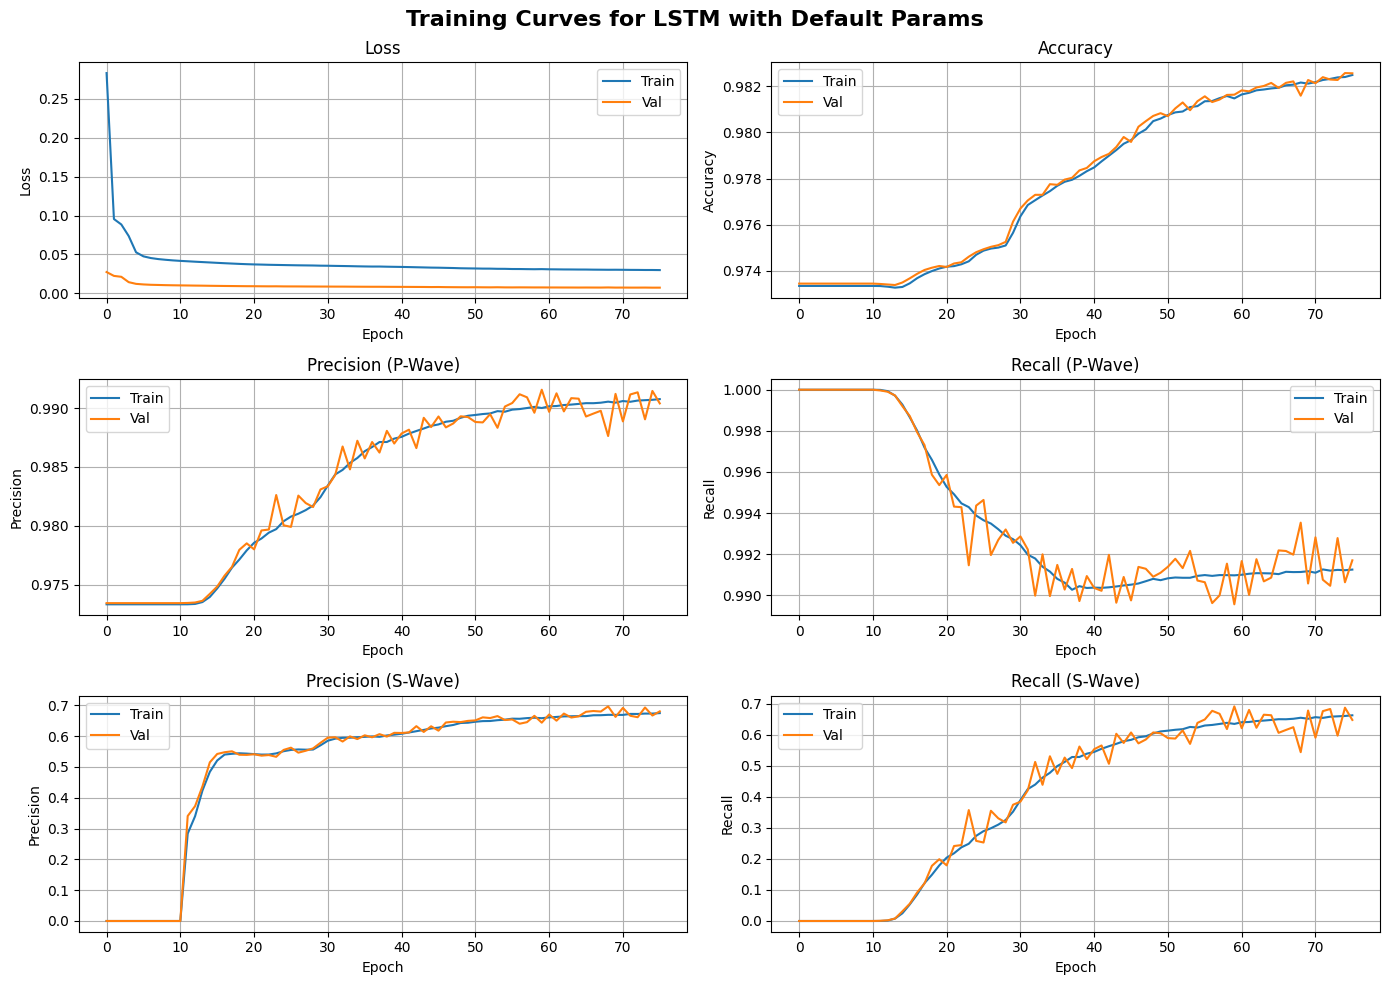

In [ ]:
plot_training_curves(lstm_hist_1, "LSTM with Default Params")

In [ ]:
summarize_best_epoch(lstm_hist_1, "LSTM with Default Params")

Model Summary for LSTM with Default Params
Best Epoch: 75
Categorical Accuracy: 0.9826

Precision and Recall per class:
  P-Wave - Precision: 0.9915, Recall: 0.9906
  S-Wave - Precision: 0.6666, Recall: 0.6868 




---
## Vary Number of Hidden Units in LSTM

In [ ]:
h_vals = [8, 32, 128]
max_num_epochs = 100
lstm_histories = {}
lstm_histories[16] = lstm_hist_1
for i, h in enumerate(h_vals):
    lstm_model = Many2ManyLSTM(input_dim=5, hidden_dim=h, output_dim=1).to(device)
    optimizer = optim.Adam(lstm_model.parameters())
    trainer = Trainer(lstm_model, optimizer, device, f"LSTM Model {i+1}")
    trainer.train(train_loader, val_loader, max_num_epochs)
    lstm_histories[h] = trainer.history

Training history for LSTM Model 1
Epoch 1
  Train - Loss: 0.45282, Acc: 0.91679, Precision (P-Wave): 0.97467, Recall (P-Wave): 0.93892, Precision (S-Wave): 0.04646, Recall (S-Wave): 0.10870
  Val   - Loss: 0.08207, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 10
  Train - Loss: 0.05264, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.01285, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 20
  Train - Loss: 0.04297, Acc: 0.97335, Precision (P-Wave): 0.97335, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.01069, Acc: 0.97345, Precision (P-Wave): 0.97345, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 30
  Train - Loss: 0.04023, Acc: 0.97345, P

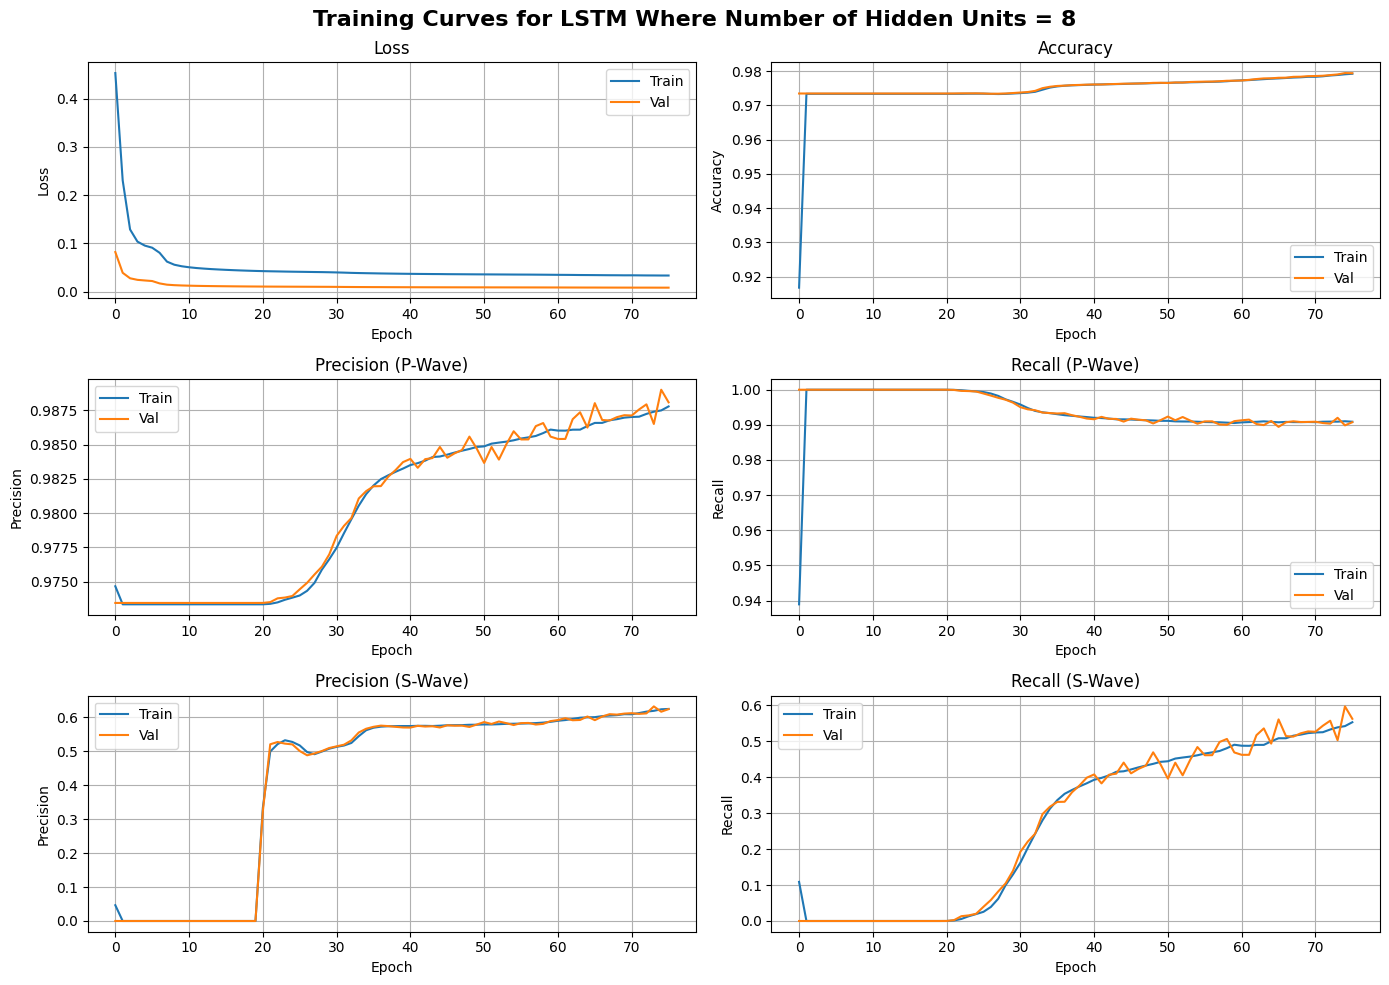

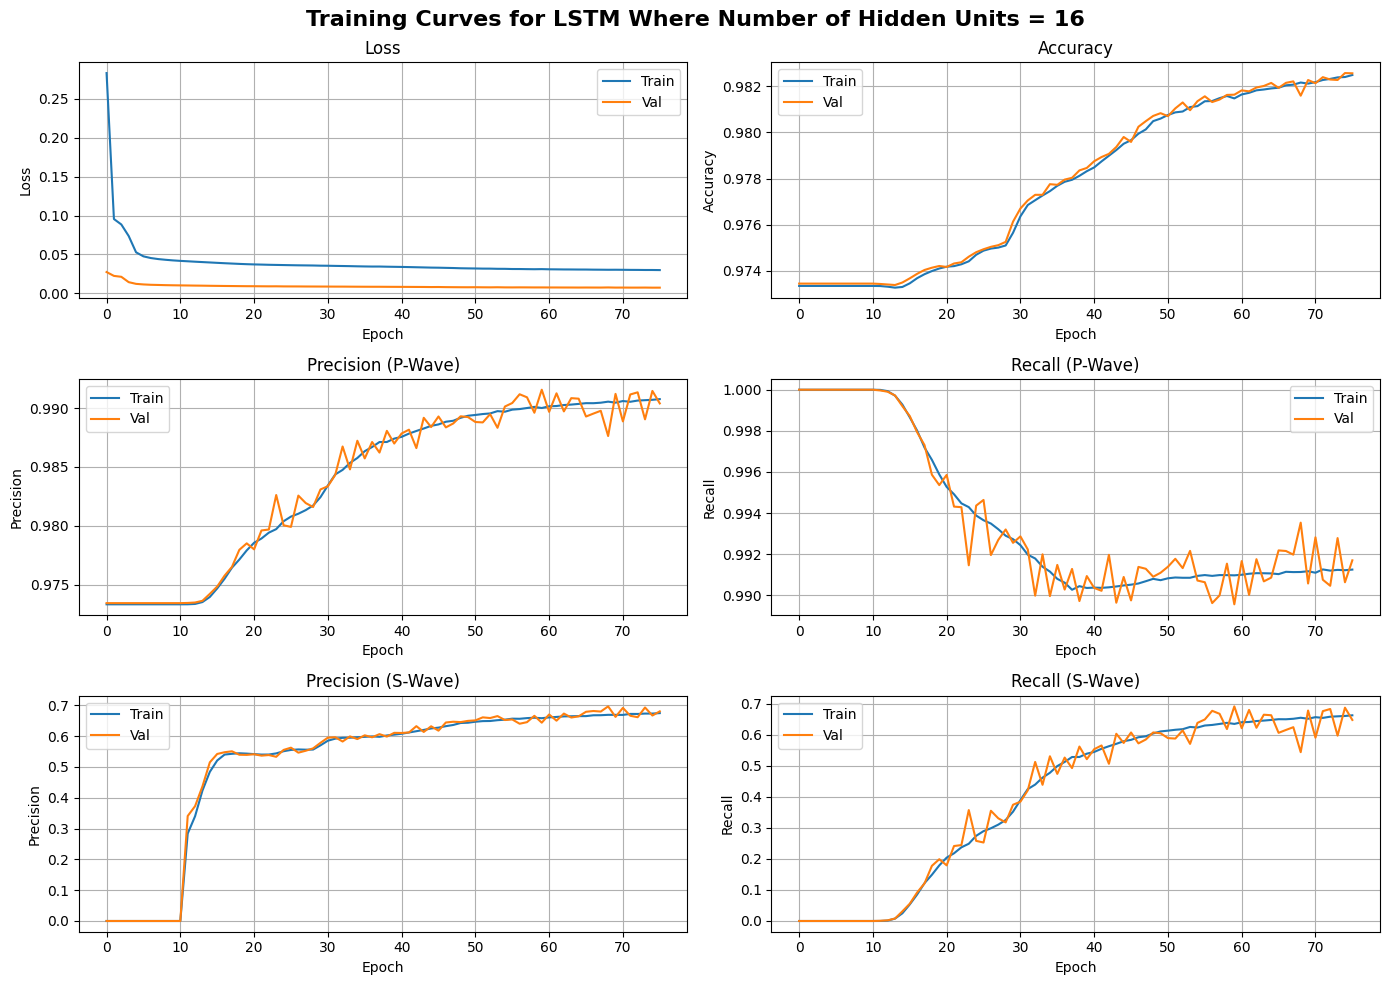

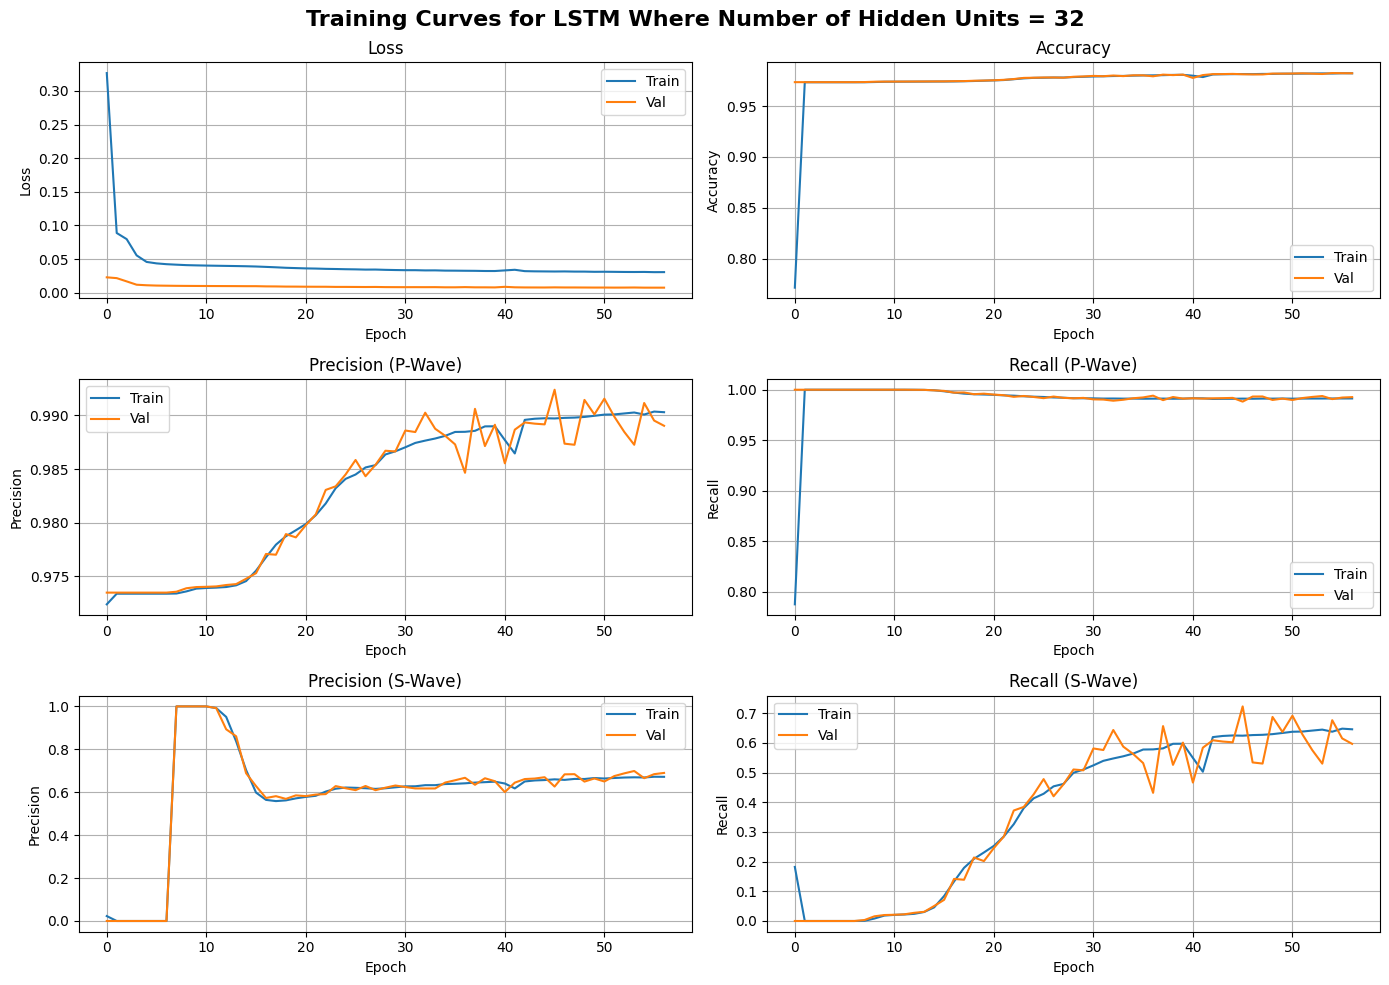

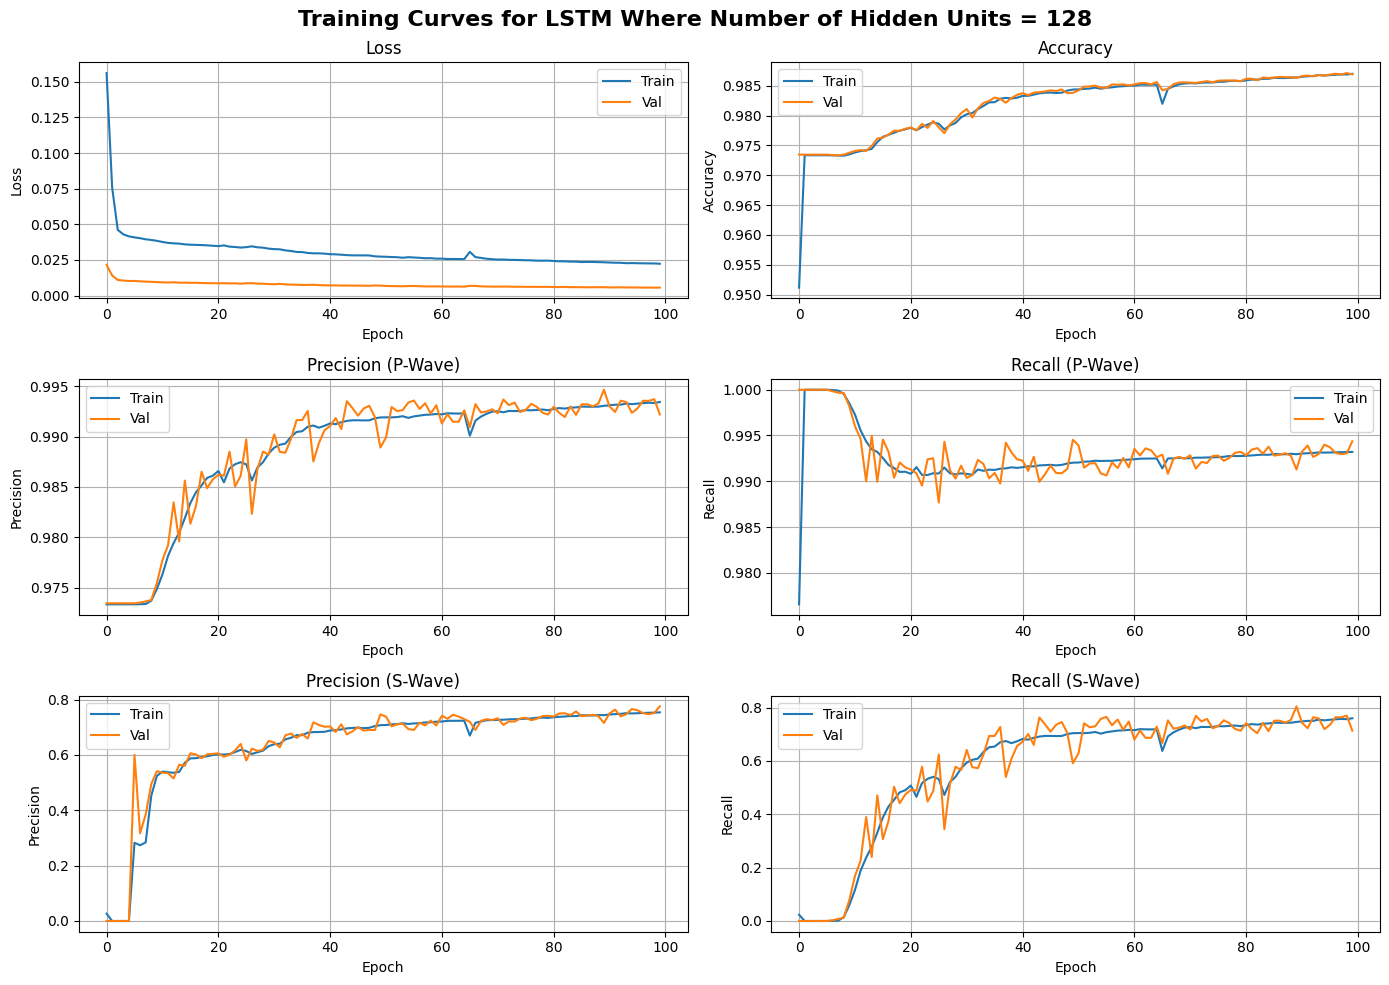

In [ ]:
plot_training_curves(lstm_histories, "LSTM", "Number of Hidden Units")

In [ ]:
h_vals.append(16)
h_vals = sorted(h_vals)
for h in h_vals:
    summarize_best_epoch(lstm_histories[h], f"LSTM with {h} Hidden Units")

Model Summary for LSTM with 8 Hidden Units
Best Epoch: 75
Categorical Accuracy: 0.9794

Precision and Recall per class:
  P-Wave - Precision: 0.9890, Recall: 0.9899
  S-Wave - Precision: 0.6160, Recall: 0.5965 


Model Summary for LSTM with 16 Hidden Units
Best Epoch: 75
Categorical Accuracy: 0.9826

Precision and Recall per class:
  P-Wave - Precision: 0.9915, Recall: 0.9906
  S-Wave - Precision: 0.6666, Recall: 0.6868 


Model Summary for LSTM with 32 Hidden Units
Best Epoch: 55
Categorical Accuracy: 0.9824

Precision and Recall per class:
  P-Wave - Precision: 0.9912, Recall: 0.9907
  S-Wave - Precision: 0.6655, Recall: 0.6763 


Model Summary for LSTM with 128 Hidden Units
Best Epoch: 99
Categorical Accuracy: 0.9871

Precision and Recall per class:
  P-Wave - Precision: 0.9937, Recall: 0.9931
  S-Wave - Precision: 0.7514, Recall: 0.7698 




---
## Bidirectional LSTM

In [ ]:
h_vals = [8, 16, 32, 128]
max_num_epochs = 100
lstm_histories_b = {}
for i, h in enumerate(h_vals):
    lstm_model_b = Many2ManyLSTM(input_dim=5, hidden_dim=h, output_dim=1, bidirectional=True).to(device)
    optimizer = optim.Adam(lstm_model_b.parameters())
    trainer_b = Trainer(lstm_model_b, optimizer, device, f"Model {i+1}")
    trainer_b.train(train_loader, val_loader, max_num_epochs)
    lstm_histories_b[h] = trainer_b.history

Training history for Model 1
Epoch 1
  Train - Loss: 0.18688, Acc: 0.97339, Precision (P-Wave): 0.97339, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000
  Val   - Loss: 0.02373, Acc: 0.97330, Precision (P-Wave): 0.97330, Recall (P-Wave): 1.00000, Precision (S-Wave): 0.00000, Recall (S-Wave): 0.00000

Epoch 10
  Train - Loss: 0.03683, Acc: 0.97594, Precision (P-Wave): 0.98305, Recall (P-Wave): 0.99239, Precision (S-Wave): 0.57346, Recall (S-Wave): 0.37423
  Val   - Loss: 0.00912, Acc: 0.97633, Precision (P-Wave): 0.98468, Recall (P-Wave): 0.99110, Precision (S-Wave): 0.57439, Recall (S-Wave): 0.43785

Epoch 20
  Train - Loss: 0.03292, Acc: 0.97947, Precision (P-Wave): 0.98854, Recall (P-Wave): 0.99040, Precision (S-Wave): 0.62276, Recall (S-Wave): 0.57985
  Val   - Loss: 0.00827, Acc: 0.97948, Precision (P-Wave): 0.99094, Recall (P-Wave): 0.98794, Precision (S-Wave): 0.60418, Recall (S-Wave): 0.67090

Epoch 30
  Train - Loss: 0.03062, Acc: 0.98134, Precis

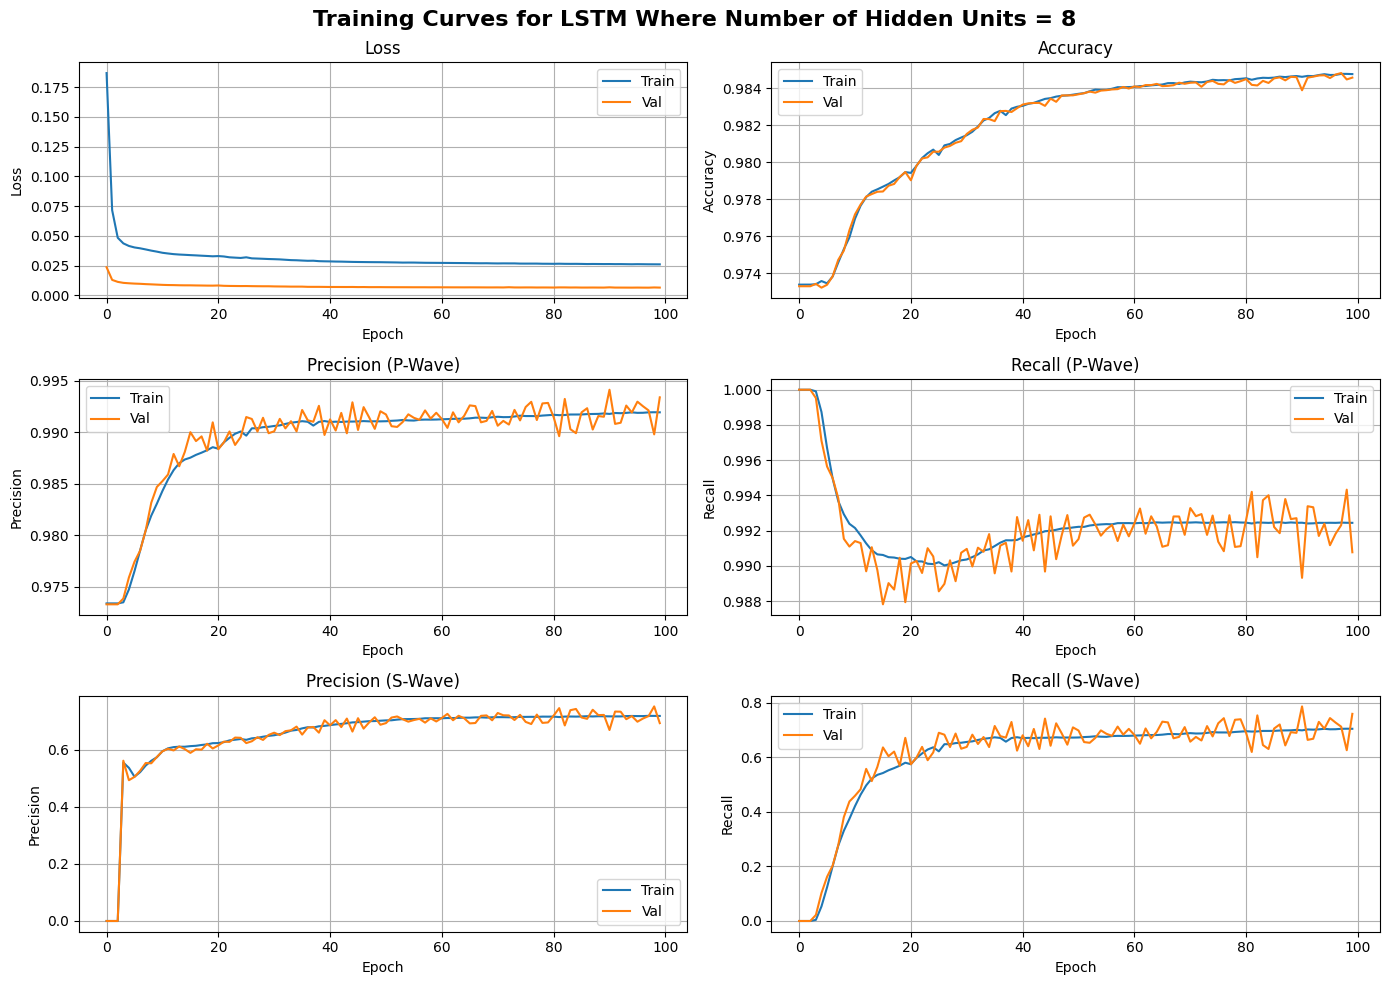

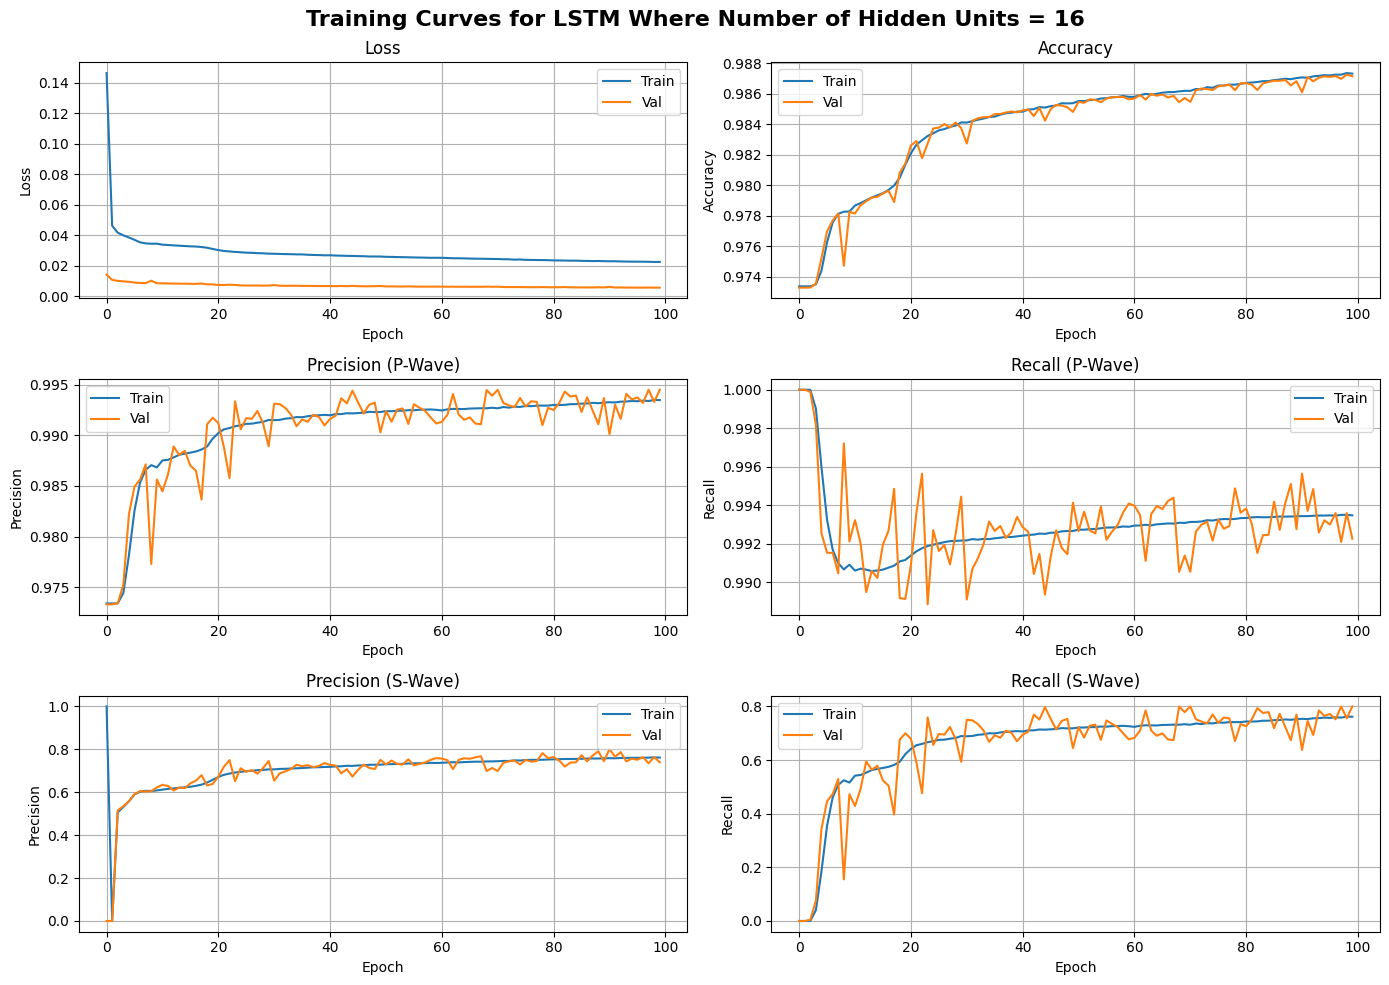

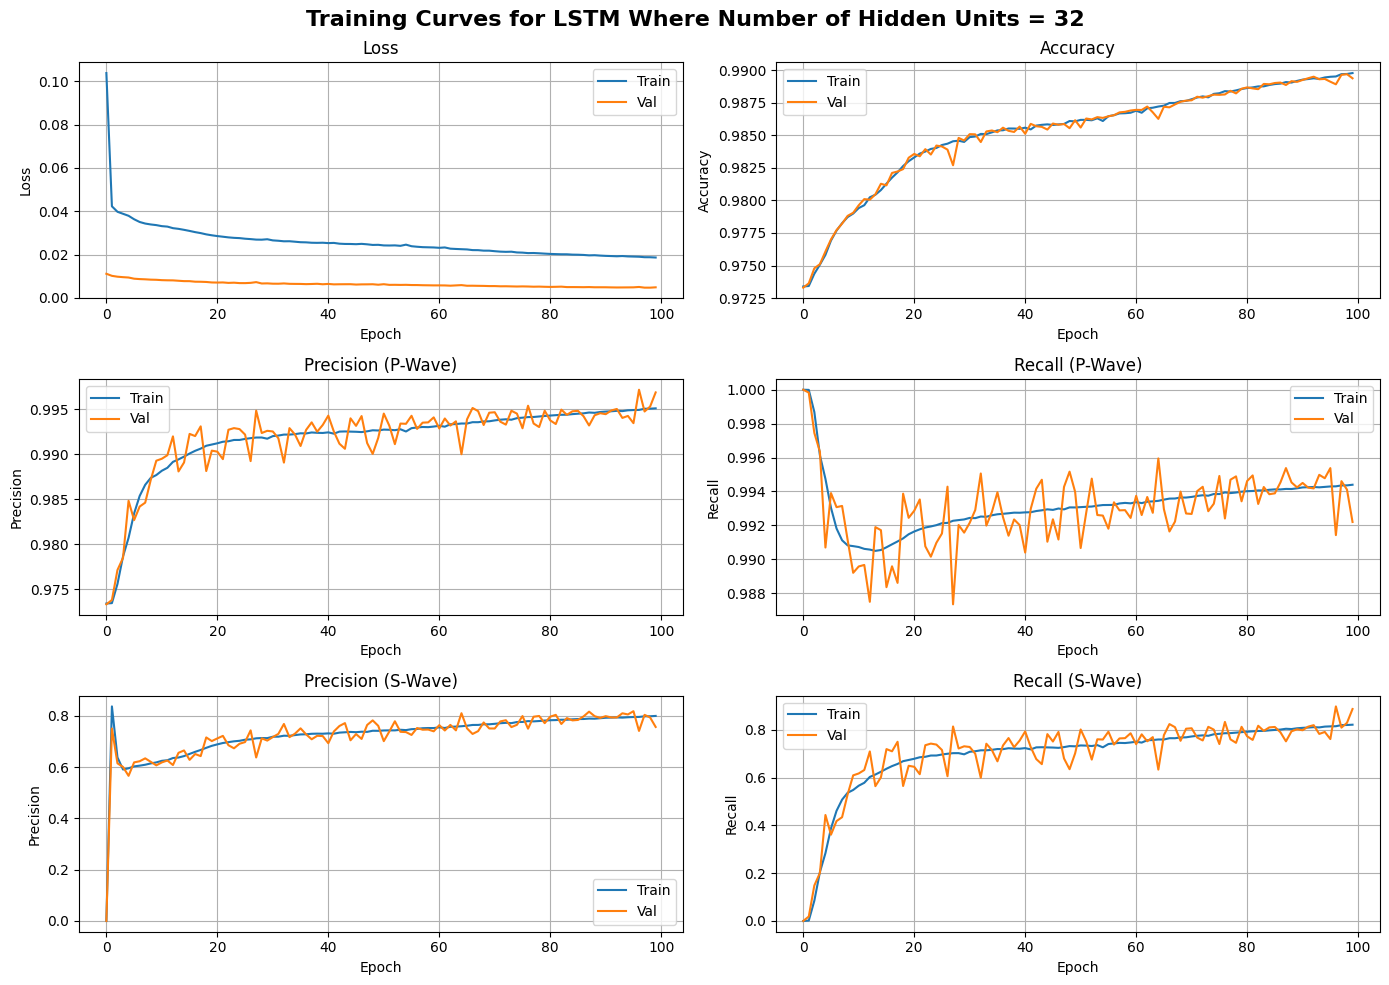

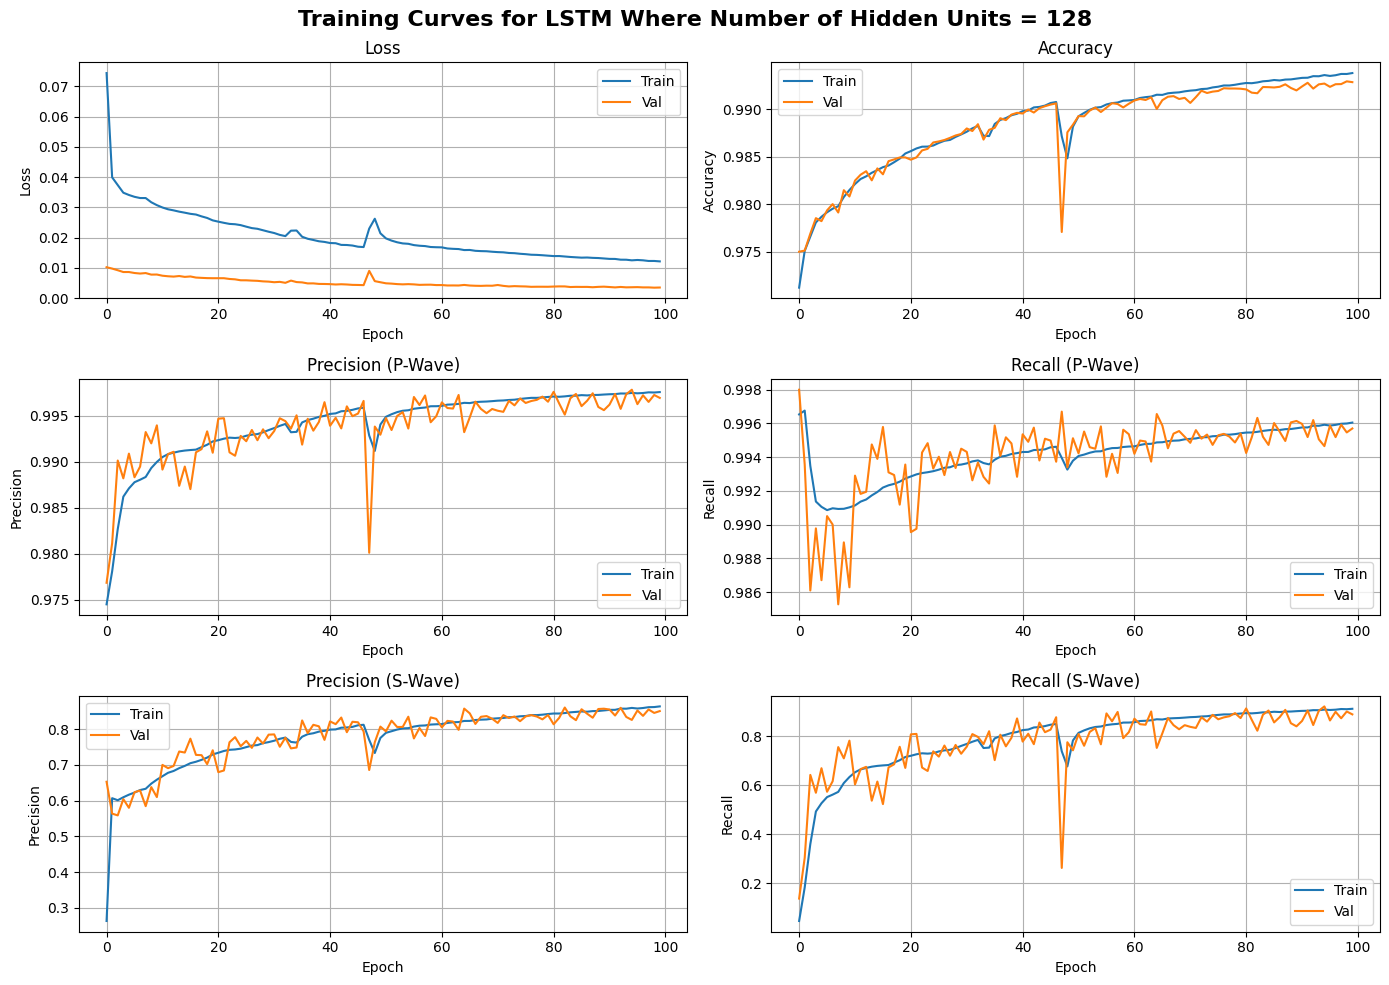

In [ ]:
plot_training_curves(lstm_histories_b, "LSTM", "Number of Hidden Units")

In [ ]:
for h in h_vals:
    summarize_best_epoch(lstm_histories_b[h], f"Bidirectional LSTM with {h} Hidden Units")

Model Summary for Bidirectional LSTM with 8 Hidden Units
Best Epoch: 98
Categorical Accuracy: 0.9848

Precision and Recall per class:
  P-Wave - Precision: 0.9921, Recall: 0.9923
  S-Wave - Precision: 0.7176, Recall: 0.7119 


Model Summary for Bidirectional LSTM with 16 Hidden Units
Best Epoch: 99
Categorical Accuracy: 0.9872

Precision and Recall per class:
  P-Wave - Precision: 0.9933, Recall: 0.9936
  S-Wave - Precision: 0.7640, Recall: 0.7558 


Model Summary for Bidirectional LSTM with 32 Hidden Units
Best Epoch: 99
Categorical Accuracy: 0.9897

Precision and Recall per class:
  P-Wave - Precision: 0.9953, Recall: 0.9941
  S-Wave - Precision: 0.7942, Recall: 0.8286 


Model Summary for Bidirectional LSTM with 128 Hidden Units
Best Epoch: 99
Categorical Accuracy: 0.9929

Precision and Recall per class:
  P-Wave - Precision: 0.9973, Recall: 0.9955
  S-Wave - Precision: 0.8451, Recall: 0.9008 




---
## Model Architecture Comparison: LSTM vs. Simple RNN

**1. The Limitations of Simple RNNs**

The Simple RNN struggled significantly with this dataset. Even under the optimal configuration (LR = 1), the model only achieved an **S-Wave Recall of 0.4321**.
*   **Instability:** As seen in the previous analysis, the RNN was highly sensitive to learning rates, with most configurations failing to learn anything beyond the majority class (0.0000 recall).
*   **Vanishing Gradients:** The poor performance suggests the RNN could not maintain long-term dependencies necessary to distinguish seismic phases over long time steps.

**2. The Superiority of LSTMs**

The transition to Long Short-Term Memory (LSTM) networks yielded a massive performance jump. Even the smallest Unidirectional LSTM (8 Hidden Units) outperformed the best optimized RNN.
*   **Metric Comparison:** The best Unidirectional LSTM (128 units) achieved an **S-Wave Recall of 0.7698**, nearly doubling the performance of the best RNN (0.4321).
*   **Reasoning:** LSTMs utilize gating mechanisms (forget, input, and output gates) that effectively prevent the vanishing gradient problem. This allows the model to retain relevant features of the P-wave and S-wave signatures over longer sequences, resulting in far more robust classification.

---

## Unidirectional vs. Bidirectional LSTM

**1. The "Future Context" Advantage**

Comparing Unidirectional and Bidirectional LSTMs reveals the importance of context in seismic signal processing.

*   **Unidirectional:** Processes the signal from start to finish ($t_0 \rightarrow t_n$). It must decide if a signal is an S-wave based only on past data.
*   **Bidirectional:** Processes the signal in both directions ($t_0 \rightarrow t_n$ and $t_n \rightarrow t_0$). This effectively allows the model to "see the future" of the waveform before classifying the current time step.

**2. Performance Impact on Minority Class**

While both architectures achieved high categorical accuracy, the Bidirectional models consistently showed superior recall for the minority class (S-waves).
*   **128 Units Comparison:**
    *   **Unidirectional:** S-Wave Recall = **0.7698**
    *   **Bidirectional:** S-Wave Recall = **0.9008**
*   **Conclusion:** The Bidirectional LSTM is the superior architecture for this task. By analyzing the waveform context both preceding and succeeding a specific point, the model can much more accurately distinguish the onset of S-waves, reducing false negatives significantly.